<a href="https://colab.research.google.com/github/thuynguyenhuit/hocsau/blob/main/Linear_Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
pd_train = pd.read_csv("https://raw.githubusercontent.com/thuynguyenhuit/hocsau/refs/heads/main/insurance.csv")

In [8]:
import pandas as pd

# Giả sử df là bộ dữ liệu insurance của bạn
# df = pd.read_csv('insurance.csv')

def check_missing_data(df):
    # Tính số lượng giá trị thiếu trên mỗi cột
    missing_count = df.isnull().sum()

    # Tính tỷ lệ phần trăm thiếu
    missing_percentage = (missing_count / len(df)) * 100

    # Tạo DataFrame để hiển thị báo cáo
    missing_report = pd.DataFrame({
        'Số lượng thiếu': missing_count,
        'Tỷ lệ (%)': missing_percentage
    })

    # Sắp xếp theo thứ tự giảm dần của số lượng thiếu
    missing_report = missing_report.sort_values(by='Số lượng thiếu', ascending=False)

    print("--- Báo cáo dữ liệu thiếu khuyết ---")
    if missing_count.sum() == 0:
        print("Chúc mừng! Bộ dữ liệu của bạn không có giá trị thiếu nào.")
    else:
        print(missing_report[missing_report['Số lượng thiếu'] > 0])

    return missing_report

# Gọi hàm
report = check_missing_data(pd_train)

--- Báo cáo dữ liệu thiếu khuyết ---
Chúc mừng! Bộ dữ liệu của bạn không có giá trị thiếu nào.


In [9]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
# Kiểm tra tên cột thực tế trong dữ liệu của bạn trước khi chạy
print("Danh sách cột hiện có:", pd_train.columns.tolist())

# 1. Xử lý cột số (age, bmi, children)
# Chúng ta dùng 'age' và 'bmi' thay cho 'Tuoi' và 'Thu_Nhap'
num_cols = ['age', 'bmi']
num_imputer = SimpleImputer(strategy='median')
pd_train[num_cols] = num_imputer.fit_transform(pd_train[num_cols])

# 2. Xử lý cột chữ (sex, smoker, region)
# Chúng ta dùng 'region' hoặc 'smoker' thay cho 'Khu_Vuc'
cat_cols = ['sex', 'smoker', 'region']
cat_imputer = SimpleImputer(strategy='most_frequent')
pd_train[cat_cols] = cat_imputer.fit_transform(pd_train[cat_cols])

print("\nĐã điền dữ liệu thiếu cho các cột: age, bmi, sex, smoker, region!")

Danh sách cột hiện có: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Đã điền dữ liệu thiếu cho các cột: age, bmi, sex, smoker, region!


In [10]:
#Xử lý các giá trị ngoại lai cho cột BMI
import numpy as np

# Giả sử đây là cột BMI trong dữ liệu của bạn
bmi_data = pd_train['bmi']

# 1. Tính Q1, Q3
Q1 = bmi_data.quantile(0.25)
Q3 = bmi_data.quantile(0.75)

# 2. Tính IQR
IQR = Q3 - Q1

# 3. Xác định ngưỡng
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# 4. Lọc dữ liệu
outliers = bmi_data[(bmi_data < lower_limit) | (bmi_data > upper_limit)]
df_cleaned = pd_train[(pd_train['bmi'] >= lower_limit) & (pd_train['bmi'] <= upper_limit)]

print(f"Ngưỡng an toàn của BMI: từ {lower_limit:.2f} đến {upper_limit:.2f}")
print(f"Số lượng Outliers bị loại bỏ: {len(outliers)}")

Ngưỡng an toàn của BMI: từ 13.70 đến 47.29
Số lượng Outliers bị loại bỏ: 9


In [5]:
print(f"Số lượng dòng ban đầu: {len(pd_train)}")
print(f"Số lượng dòng sau khi lọc Outliers: {len(df_cleaned)}")
print(f"Tổng số dòng bị loại bỏ: {len(pd_train) - len(df_cleaned)}")

Số lượng dòng ban đầu: 1338
Số lượng dòng sau khi lọc Outliers: 1329
Tổng số dòng bị loại bỏ: 9


In [12]:
#one-hot encoding

# truyền df_cleaned vào làm tham số đầu tiên
pd_train = pd.get_dummies(df_cleaned, columns=['sex', 'smoker', 'region'], drop_first=True)

print("Dữ liệu sau khi mã hóa thành công:")
display(pd_train.head())

Dữ liệu sau khi mã hóa thành công:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19.0,27.900,0,16884.92400,False,True,False,False,True
1,18.0,33.770,1,1725.55230,True,False,False,True,False
2,28.0,33.000,3,4449.46200,True,False,False,True,False
3,33.0,22.705,0,21984.47061,True,False,True,False,False
4,32.0,28.880,0,3866.85520,True,False,True,False,False


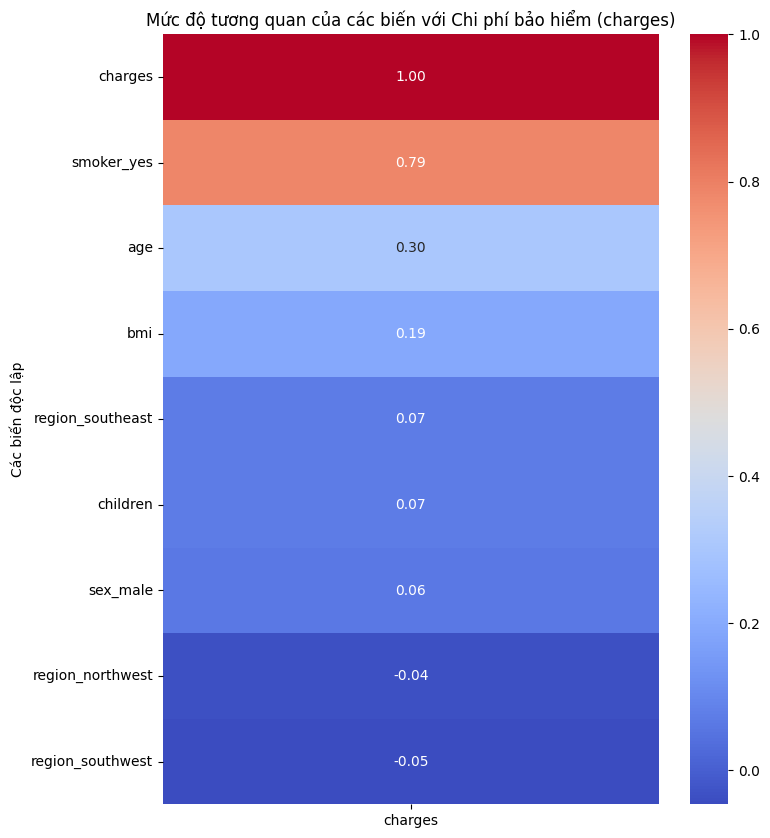

Bảng giá trị tương quan chi tiết:
                   charges
charges           1.000000
smoker_yes        0.785912
age               0.302022
bmi               0.193196
region_southeast  0.071597
children          0.069739
sex_male          0.063394
region_northwest -0.037704
region_southwest -0.045906


In [14]:
#Đo tương quan giữa các biến độc lập với biến phụ thuộc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tính toán ma trận tương quan cho toàn bộ DataFrame
# Lưu ý: pd_train là biến chứa dữ liệu đã mã hóa One-Hot của bạn
corr_matrix = pd_train.corr()

# 2. Trích xuất riêng tương quan của các biến với biến mục tiêu 'charges'
# Sắp xếp từ cao xuống thấp để dễ theo dõi
target_correlation = corr_matrix[['charges']].sort_values(by='charges', ascending=False)

# 3. Trực quan hóa bằng Heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(target_correlation, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)

plt.title('Mức độ tương quan của các biến với Chi phí bảo hiểm (charges)')
plt.ylabel('Các biến độc lập')
plt.show()

# 4. In ra bảng giá trị số cụ thể
print("Bảng giá trị tương quan chi tiết:")
print(target_correlation)